# Probe Analysis
Phoneme identity + L1 accent linear probing across Whisper encoder layers.
Compares baseline (`openai/whisper-small`) vs LoRA fine-tuned model.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

PHONEME_PATH = Path("results/phoneme_probe/phoneme_probe_scripted.json")
ACCENT_PATH  = Path("results/accent_probe/accent_probe_scripted.json")
RESULTS_DIR = Path("results/probe_anal")

with open(PHONEME_PATH) as f: phoneme_results = json.load(f)
with open(ACCENT_PATH)  as f: accent_results  = json.load(f)

MODELS   = list(phoneme_results.keys())
N_LAYERS = len(list(phoneme_results[MODELS[0]].keys()))
LAYERS   = [int(k) for k in phoneme_results[MODELS[0]].keys()]
print(f"Models: {MODELS}")
print(f"Layers: {LAYERS}")

Models: ['baseline']
Layers: [0, 1, 2, 3, 4, 5, 6]


In [7]:
def get_layer_metric(results, model, metric="accuracy", probe_key="global"):
    out = []
    for li in LAYERS:
        entry = results[model].get(str(li), {})
        # Handle both structures:
        # accent probe: { "global": { "accuracy": ... }, "chance_accuracy": ... }
        # phoneme probe: { "accuracy": ..., "macro_f1": ..., ... }
        if probe_key in entry:
            val = entry[probe_key].get(metric, float("nan"))
        else:
            val = entry.get(metric, float("nan"))
        out.append(val)
    return np.array(out)

COLORS = {"baseline": "#4e79a7", "lora": "#f28e2b"}
LABELS = {"baseline": "Baseline (frozen)", "lora": "LoRA fine-tuned"}

# In the notebook, add this debug cell:
print("Phoneme keys:", list(phoneme_results.keys()))
print("Accent keys:", list(accent_results.keys()))
print("Layers from phoneme:", LAYERS)
print("Layers from accent:", [int(k) for k in accent_results["baseline"].keys()])

# Test get_layer_metric directly:
vals = get_layer_metric(phoneme_results, "baseline", metric="accuracy")
print("Phoneme baseline accuracy by layer:", vals)

Phoneme keys: ['baseline']
Accent keys: ['baseline', 'lora']
Layers from phoneme: [0, 1, 2, 3, 4, 5, 6]
Layers from accent: [0, 1, 2, 3, 4, 5, 6]
Phoneme baseline accuracy by layer: [0.33743333 0.57346667 0.6447     0.70153333 0.7384     0.77056667
 0.80113333]


## 1. Phoneme Probe — Accuracy by Layer

[0.33743333 0.57346667 0.6447     0.70153333 0.7384     0.77056667
 0.80113333]
[0.32718034 0.54004388 0.6091733  0.67412982 0.71976602 0.75507033
 0.79153561]


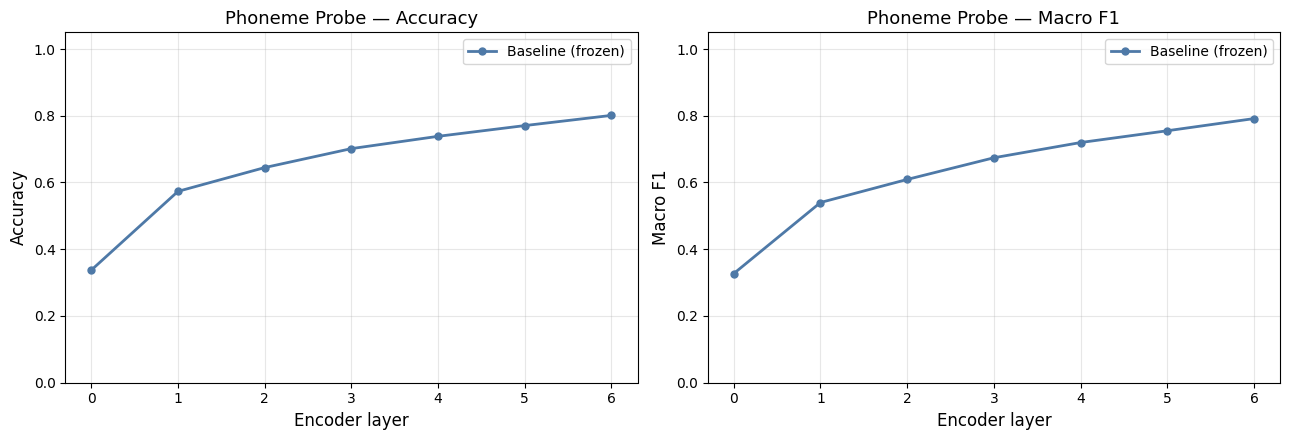

Saved: results/phoneme_probe_by_layer.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

metrics = [("accuracy", "Accuracy"), ("macro_f1", "Macro F1")]

for ax, (metric, ylabel) in zip(axes, metrics):
    for model in MODELS:
        if model not in phoneme_results: continue
        vals = get_layer_metric(phoneme_results, model, metric=metric)
        print(vals)
        ax.plot(LAYERS, vals, marker="o", label=LABELS.get(model, model),
                color=COLORS.get(model, "gray"), linewidth=2, markersize=5)
    # chance
    chance = phoneme_results[MODELS[0]][str(LAYERS[0])].get("chance_accuracy", None)
    if chance:
        ax.axhline(chance, linestyle="--", color="gray", alpha=0.5, label=f"Chance ({chance:.3f})")
    ax.set_xlabel("Encoder layer", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Phoneme Probe — {ylabel}", fontsize=13)
    ax.set_xticks(LAYERS)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("results/phoneme_probe_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/phoneme_probe_by_layer.png")

## 2. Accent Probe — Accuracy by Layer

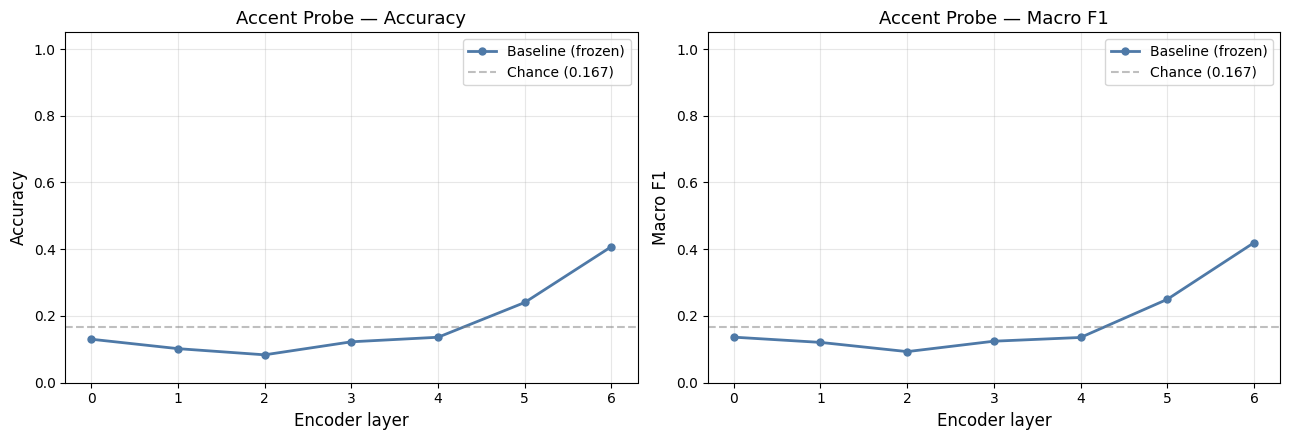

Saved: results/accent_probe_by_layer.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

for ax, (metric, ylabel) in zip(axes, metrics):
    for model in MODELS:
        if model not in accent_results: continue
        vals = get_layer_metric(accent_results, model, metric=metric)
        ax.plot(LAYERS, vals, marker="o", label=LABELS.get(model, model),
                color=COLORS.get(model, "gray"), linewidth=2, markersize=5)
    chance = accent_results[MODELS[0]][str(LAYERS[0])].get("chance_accuracy", None)
    if chance:
        ax.axhline(chance, linestyle="--", color="gray", alpha=0.5, label=f"Chance ({chance:.3f})")
    ax.set_xlabel("Encoder layer", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(f"Accent Probe — {ylabel}", fontsize=13)
    ax.set_xticks(LAYERS)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("results/accent_probe_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/accent_probe_by_layer.png")

## 3. Combined — Phoneme vs Accent by Layer (key thesis figure)
The story: does LoRA preserve phoneme decodability while reducing accent decodability?

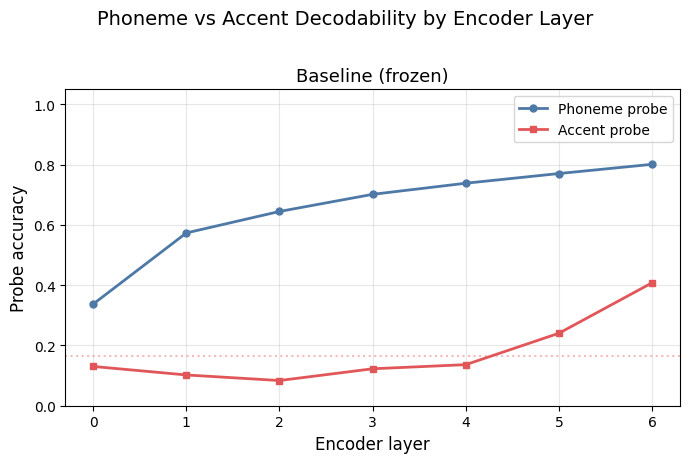

Saved: results/phoneme_vs_accent_by_layer.png


In [10]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 4.5), sharey=True)
if len(MODELS) == 1: axes = [axes]

for ax, model in zip(axes, MODELS):
    ph_acc = get_layer_metric(phoneme_results, model, metric="accuracy") if model in phoneme_results else None
    ac_acc = get_layer_metric(accent_results,  model, metric="accuracy") if model in accent_results  else None

    if ph_acc is not None:
        ax.plot(LAYERS, ph_acc, marker="o", color="#4e79a7", linewidth=2,
                markersize=5, label="Phoneme probe")
    if ac_acc is not None:
        ax.plot(LAYERS, ac_acc, marker="s", color="#e15759", linewidth=2,
                markersize=5, label="Accent probe")

    # chance lines
    ph_chance = phoneme_results.get(model, {}).get(str(LAYERS[0]), {}).get("chance_accuracy")
    ac_chance = accent_results.get(model,  {}).get(str(LAYERS[0]), {}).get("chance_accuracy")
    if ph_chance: ax.axhline(ph_chance, linestyle=":", color="#4e79a7", alpha=0.4)
    if ac_chance: ax.axhline(ac_chance, linestyle=":", color="#e15759", alpha=0.4)

    ax.set_title(LABELS.get(model, model), fontsize=13)
    ax.set_xlabel("Encoder layer", fontsize=12)
    ax.set_ylabel("Probe accuracy", fontsize=12)
    ax.set_xticks(LAYERS)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 1.05)

plt.suptitle("Phoneme vs Accent Decodability by Encoder Layer", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/phoneme_vs_accent_by_layer.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/phoneme_vs_accent_by_layer.png")

## 4. Delta plot — LoRA effect on each probe
LoRA accuracy minus baseline accuracy per layer. Positive = LoRA helps, negative = LoRA hurts.

In [11]:
if "baseline" in phoneme_results and "lora" in phoneme_results:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=False)

    for ax, (results, title) in zip(axes, [
        (phoneme_results, "Phoneme Probe Δ (LoRA − Baseline)"),
        (accent_results,  "Accent Probe Δ (LoRA − Baseline)"),
    ]):
        if "baseline" not in results or "lora" not in results:
            ax.set_title(title + " [missing data]")
            continue
        base_acc = get_layer_metric(results, "baseline")
        lora_acc = get_layer_metric(results, "lora")
        delta    = lora_acc - base_acc
        colors   = ["#59a14f" if d >= 0 else "#e15759" for d in delta]
        ax.bar(LAYERS, delta, color=colors, alpha=0.8, edgecolor="white")
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_xlabel("Encoder layer", fontsize=12)
        ax.set_ylabel("Δ Accuracy", fontsize=12)
        ax.set_title(title, fontsize=13)
        ax.set_xticks(LAYERS)
        ax.grid(alpha=0.3, axis="y")

    plt.tight_layout()
    plt.savefig("results/probe_delta_by_layer.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: results/probe_delta_by_layer.png")
else:
    print("Need both baseline and lora results for delta plot")

Need both baseline and lora results for delta plot


## 5. Numerical summary table

In [13]:
import pandas as pd

rows = []
for model in MODELS:
    for li in LAYERS:
        ph = phoneme_results.get(model, {}).get(str(li), {})
        ac = accent_results.get(model,  {}).get(str(li), {}).get("global", {})
        rows.append({
            "model":        model,
            "layer":        li,
            "phoneme_acc":  ph.get("accuracy",  float("nan")),
            "phoneme_f1":   ph.get("macro_f1", float("nan")),
            "accent_acc":   ac.get("accuracy",  float("nan")),
            "accent_f1":    ac.get("macro_f1", float("nan")),
        })

df = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_rows", 50)
display(df)
df.to_csv("results/probe_summary.csv", index=False)
print("Saved: results/probe_summary.csv")

,model,layer,phoneme_acc,phoneme_f1,accent_acc,accent_f1
0,baseline,0,0.337,0.327,0.130,0.137
1,baseline,1,0.573,0.540,0.102,0.121
2,baseline,2,0.645,0.609,0.084,0.093
3,baseline,3,0.702,0.674,0.123,0.124
4,baseline,4,0.738,0.720,0.136,0.136
5,baseline,5,0.771,0.755,0.241,0.250
6,baseline,6,0.801,0.792,0.408,0.420


Saved: results/probe_summary.csv


## 6. Within-phoneme accent probe (if available)
Per-phoneme accent decodability — which phones carry the most accent signal?

In [14]:
# Check if within-phoneme results exist
sample_layer = str(LAYERS[-1])
has_wp = any(
    "within_phoneme" in accent_results.get(m, {}).get(sample_layer, {})
    for m in MODELS
)
print(f"Within-phoneme results available: {has_wp}")

if has_wp:
    # Plot mean within-phoneme accent acc by layer
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for model in MODELS:
        if model not in accent_results: continue
        wp_accs = []
        for li in LAYERS:
            entry = accent_results[model].get(str(li), {})
            wp_acc = entry.get("mean_within_phoneme_acc", float("nan"))
            wp_accs.append(wp_acc)
        ax.plot(LAYERS, wp_accs, marker="o", label=LABELS.get(model, model),
                color=COLORS.get(model, "gray"), linewidth=2, markersize=5)
    ax.set_xlabel("Encoder layer"); ax.set_ylabel("Within-phoneme accent acc")
    ax.set_title("Accent decodability controlling for phoneme identity")
    ax.set_xticks(LAYERS); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/within_phoneme_accent_by_layer.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Top phones by accent decodability at the last layer
    for model in MODELS:
        wp_data = accent_results.get(model, {}).get(sample_layer, {}).get("within_phoneme", {})
        if not wp_data: continue
        phone_accs = {ph: v["accuracy"] for ph, v in wp_data.items() if not np.isnan(v["accuracy"])}
        sorted_phones = sorted(phone_accs.items(), key=lambda x: -x[1])
        print(f"\n[{model}] Top 10 phones by accent decodability (layer {sample_layer}):")
        for ph, acc in sorted_phones[:10]:
            print(f"  {ph:6s}  {acc:.3f}")

Within-phoneme results available: False
